In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split
import os

In [4]:
# LOADING NORMALISED DATA

X = pd.read_csv("KIRC_vst_normalized.csv", index_col=0)
y = pd.read_csv("KIRC_labels_final.csv", index_col=0)

In [5]:
# DIVISION BETWEEN TRAINING AND TESTING (80%/20%)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # THE SAME PERCENTAGE OF PATIENTS IN BOTH GROUPS
)

print(f"Training data: {X_train.shape}")
print(f"Test data:    {X_test.shape}")

Training data: (487, 35708)
Test data:    (122, 35708)


In [6]:
# SELECTING THE TOP 100 (SELECTOR CONFIGURATION)

selector = SelectKBest(score_func=mutual_info_classif, k=100)

In [8]:
# LEARNING (FIT)

selector.fit(X_train, y_train.values.ravel())

,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function mut...002191EACECA0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",100


In [9]:
# TRANSFORMATION (COLUMN RESTRICTION)

X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

In [10]:
# RECOVERY OF GENE NAMES (SKLEARN RETURNS A CLEAN NUMBER MATRIX)

selected_indices = selector.get_support(indices=True)
selected_gene_names = X.columns[selected_indices]

In [11]:
# EXCHANGE WITH RETURN UNDER THE TABLE

X_train_selected = pd.DataFrame(X_train_selected, index=X_train.index, columns=selected_gene_names)
X_test_selected = pd.DataFrame(X_test_selected, index=X_test.index, columns=selected_gene_names)

In [12]:
print("TOP 10 selected genes:")
print(selected_gene_names[:10].tolist())

TOP 10 selected genes:
['ENSG00000008196.13', 'ENSG00000014257.16', 'ENSG00000035720.8', 'ENSG00000036828.17', 'ENSG00000061656.10', 'ENSG00000073060.16', 'ENSG00000074803.20', 'ENSG00000075673.12', 'ENSG00000079101.16', 'ENSG00000079691.18']


In [13]:
# DOWNLOADING RESULTS FOR SPECIFIC GENES

scores = selector.scores_[selected_indices]

In [14]:
# TABLE FOR THE CHART

gene_scores = pd.DataFrame({'Gene': selected_gene_names, 'MI_Score': scores})
gene_scores = gene_scores.sort_values(by='MI_Score', ascending=False).head(20) # Top 20

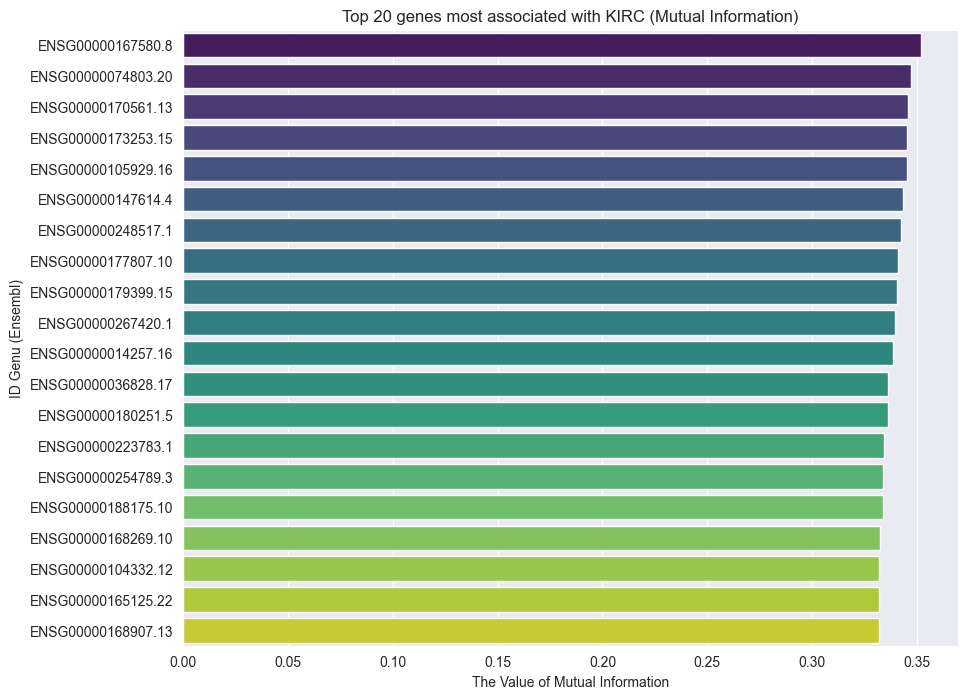

In [15]:
# DRAWING CHART

plt.figure(figsize=(10, 8))
sns.barplot(
    x='MI_Score',
    y='Gene',
    data=gene_scores,
    palette='viridis',
    hue='Gene',
    legend=False
)

plt.title('Top 20 genes most associated with KIRC (Mutual Information)')
plt.xlabel('The Value of Mutual Information')
plt.ylabel('ID Genu (Ensembl)')
plt.savefig('Top-20-MI-Score', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
output_dir = 'processed_data'
os.makedirs(output_dir, exist_ok=True)

In [17]:
# SAVING DATA

X_train_selected.to_csv(os.path.join(output_dir, "X_train_selected_100.csv"))
X_test_selected.to_csv(os.path.join(output_dir, "X_test_selected_100.csv"))

In [18]:
# LABELS

y_train.to_csv(os.path.join(output_dir, "y_train.csv"))
y_test.to_csv(os.path.join(output_dir, "y_test.csv"))